In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.datasets import make_moons

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

In [54]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset Shape:", X.shape)

Dataset Shape: (1797, 64)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

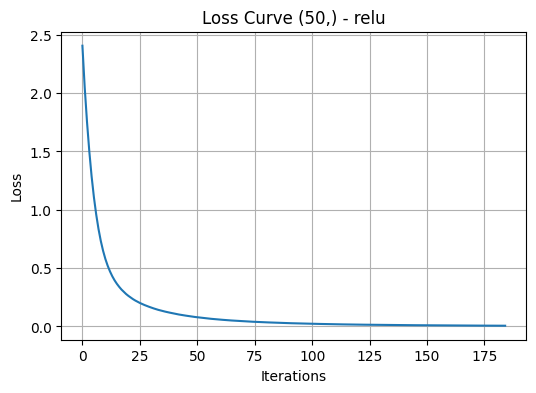

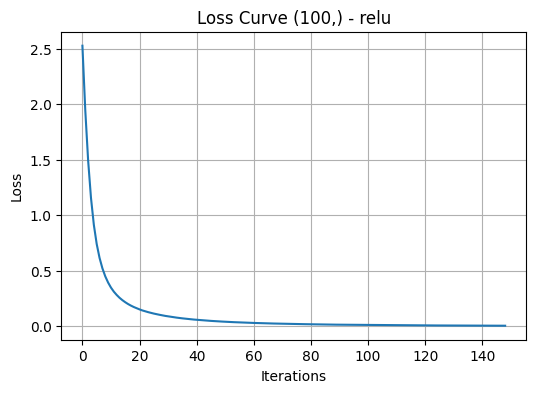

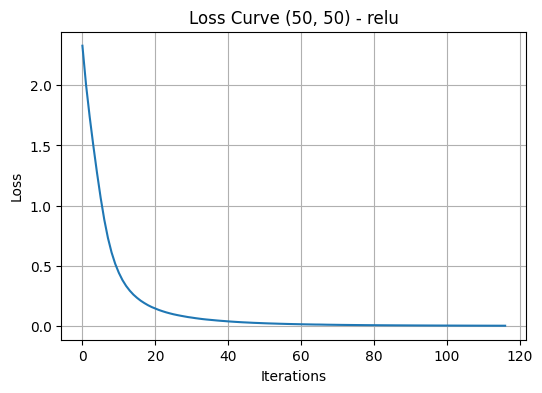

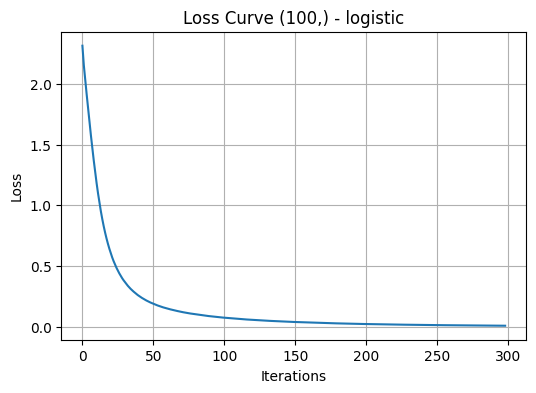

In [56]:
models = [

    ((50,), 'relu'),

    ((100,), 'relu'),

    ((50,50), 'relu'),

    ((100,), 'logistic')
]

results = []

for hidden, activation in models:

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        max_iter=300,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    predictions = mlp.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append([
        str(hidden),
        activation,
        round(accuracy,4)
    ])

    plt.figure(figsize=(6,4))

    plt.plot(mlp.loss_curve_)

    plt.title(
        f"Loss Curve {hidden} - {activation}"
    )

    plt.xlabel("Iterations")
    plt.ylabel("Loss")

    plt.grid()

    plt.show()

In [57]:
sklearn_results = pd.DataFrame(
    results,
    columns=[
        "Hidden Layers",
        "Activation",
        "Accuracy"
    ]
)

print(sklearn_results)

  Hidden Layers Activation  Accuracy
0         (50,)       relu    0.9722
1        (100,)       relu    0.9806
2      (50, 50)       relu    0.9778
3        (100,)   logistic    0.9778


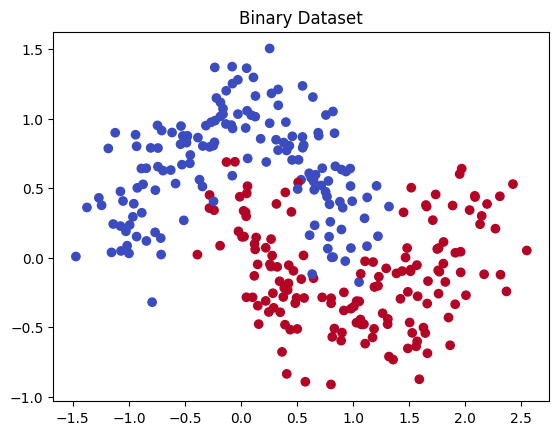

In [58]:
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

y = y.reshape(-1,1)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.flatten(),
    cmap='coolwarm'
)

plt.title("Binary Dataset")
plt.show()

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
class SimpleANN:

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        lr=0.1
    ):

        self.lr = lr

        self.W1 = np.random.randn(
            input_size,
            hidden_size
        ) * 0.1

        self.b1 = np.zeros(
            (1, hidden_size)
        )

        self.W2 = np.random.randn(
            hidden_size,
            output_size
        ) * 0.1

        self.b2 = np.zeros(
            (1, output_size)
        )

        self.losses = []

    def sigmoid(self, z):

        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):

        return a * (1 - a)

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1

        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2

        self.a2 = self.sigmoid(self.z2)

        return self.a2

    def loss(self, y, output):

        return -np.mean(
            y*np.log(output+1e-8)
            +
            (1-y)*np.log(1-output+1e-8)
        )

    def backward(self, X, y):

        m = len(X)

        dz2 = self.a2 - y

        dW2 = np.dot(
            self.a1.T,
            dz2
        ) / m

        db2 = np.sum(
            dz2,
            axis=0,
            keepdims=True
        ) / m

        dz1 = np.dot(
            dz2,
            self.W2.T
        ) * self.sigmoid_derivative(
            self.a1
        )

        dW1 = np.dot(
            X.T,
            dz1
        ) / m

        db1 = np.sum(
            dz1,
            axis=0,
            keepdims=True
        ) / m

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs):

        for epoch in range(epochs):

            output = self.forward(X)

            loss = self.loss(y, output)

            self.losses.append(loss)

            self.backward(X, y)

    def predict(self, X):

        output = self.forward(X)

        return (output > 0.5).astype(int)

In [61]:
ann = SimpleANN(
    input_size=2,
    hidden_size=5,
    output_size=1,
    lr=0.5
)

ann.train(
    X_train,
    y_train,
    epochs=1000
)

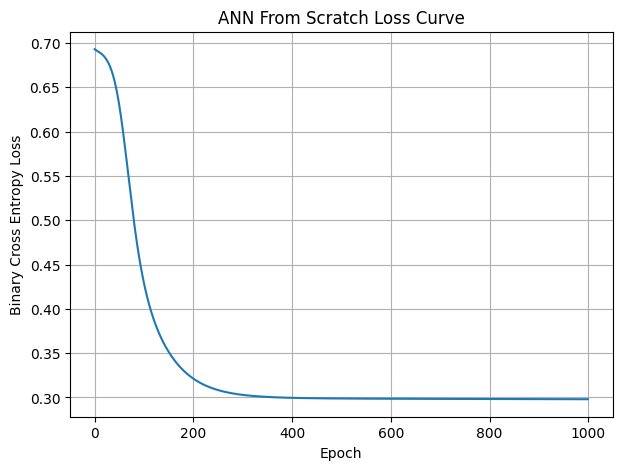

In [62]:
plt.figure(figsize=(7,5))

plt.plot(ann.losses)

plt.title(
    "ANN From Scratch Loss Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Binary Cross Entropy Loss")

plt.grid()

plt.show()

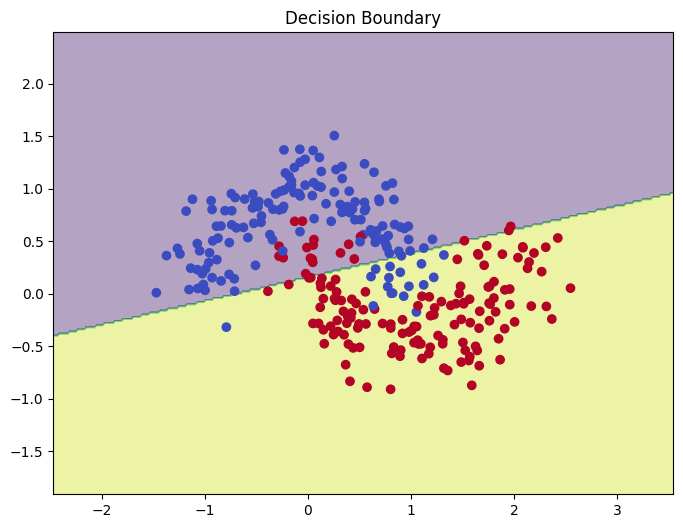

In [63]:
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

Z = ann.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.flatten(),
    cmap='coolwarm'
)

plt.title(
    "Decision Boundary"
)

plt.show()

In [64]:
predictions = ann.predict(X_test)

manual_accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Manual ANN Accuracy:",
    round(manual_accuracy,4)
)

Manual ANN Accuracy: 0.8667


In [65]:
best_sklearn = sklearn_results.loc[
    sklearn_results["Accuracy"].idxmax()
]

comparison = pd.DataFrame({

    "Model":[
        "Best sklearn MLP",
        "Manual ANN"
    ],

    "Accuracy":[
        best_sklearn["Accuracy"],
        round(manual_accuracy,4)
    ]
})

print(comparison)

              Model  Accuracy
0  Best sklearn MLP    0.9806
1        Manual ANN    0.8667
